#
# Saudi Arabic NLP — Exploratory Data Analysis (EDA)
#


In [8]:
!pip install -q arabic_reshaper python-bidi wordcloud


In [9]:
from google.colab import files
uploaded = files.upload()  # select Clean_saudi_NLP.csv


Saving Clean_saudi_NLP.csv to Clean_saudi_NLP (1).csv


In [10]:
!wget -q -O NotoSansArabic.ttf "https://raw.githubusercontent.com/google/fonts/main/ofl/notosansarabic/NotoSansArabic%5Bwdth%2Cwght%5D.ttf"


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import arabic_reshaper
from bidi.algorithm import get_display
from collections import Counter

FONT_PATH = "NotoSansArabic.ttf"
arabic_font = fm.FontProperties(fname=FONT_PATH)

def ar(text):
    """Reshape Arabic text so it renders correctly in matplotlib (data labels only)."""
    reshaped = arabic_reshaper.reshape(str(text))
    return get_display(reshaped)



In [12]:
df = pd.read_csv("Clean_saudi_NLP.csv")
print(f"Total samples: {len(df)}")
df.head()


Total samples: 308


,text,text_clean,intent,sentiment,word_count
0,متى تنتهي عروض اليوم الوطني؟,متى تنتهي عروض اليوم الوطني؟,Inquiry,Neutral,5
1,الشحنة تاخرت مررررررره,الشحنة تاخرت مرره,Complaint,Negative,3
2,التعامل ممتاز,التعامل ممتاز,Positive Feedback,Positive,2
3,وش الفرق بين كل هالخدمات لان صراحه واجد لخبطت ...,وش الفرق بين كل هالخدمات لان صراحه واجد لخبطت ...,Inquiry,Neutral,10
4,هل أقدر اغير طريقة الدفع؟,هل اقدر اغير طريقة الدفع؟,Inquiry,Neutral,5


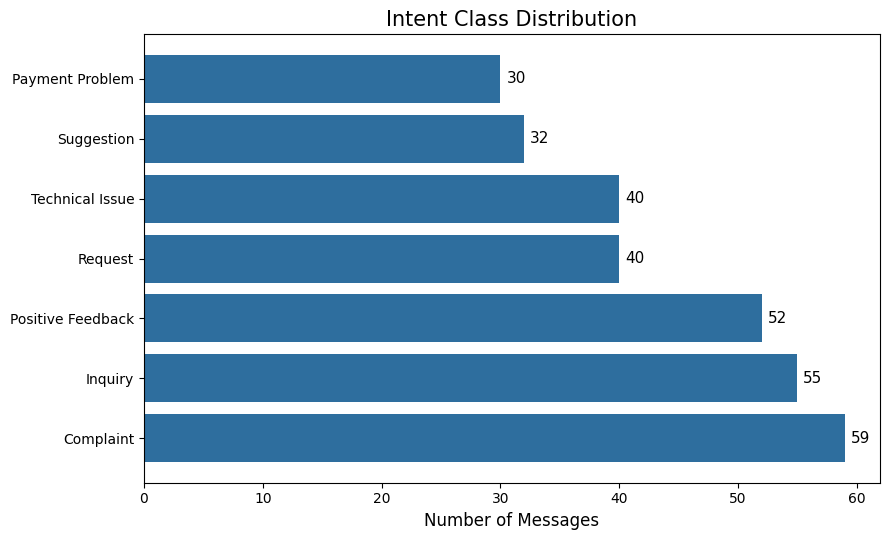

In [13]:
fig, ax = plt.subplots(figsize=(9, 5.5))
intent_counts = df['intent'].value_counts()
bars = ax.barh(intent_counts.index, intent_counts.values, color='#2E6E9E')
ax.set_title("Intent Class Distribution", fontsize=15)
ax.set_xlabel("Number of Messages", fontsize=12)
for bar, val in zip(bars, intent_counts.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=11)
plt.tight_layout()
plt.show()


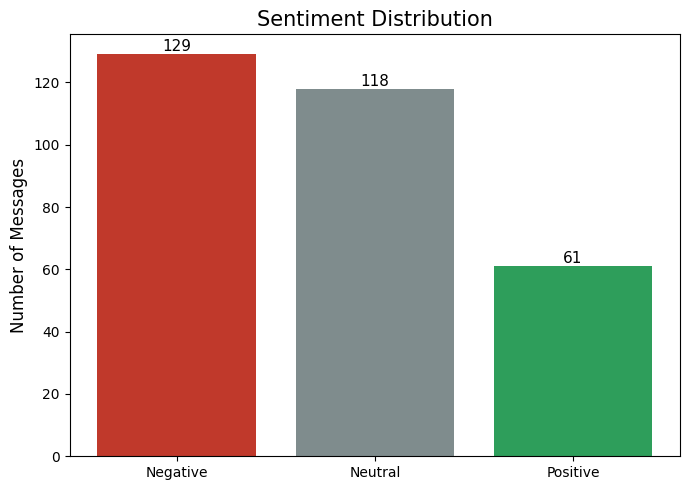

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
sent_counts = df['sentiment'].value_counts()
colors = {'Positive': '#2E9E5B', 'Negative': '#C0392B', 'Neutral': '#7F8C8D'}
bar_colors = [colors.get(s, '#888888') for s in sent_counts.index]
bars = ax.bar(sent_counts.index, sent_counts.values, color=bar_colors)
ax.set_title("Sentiment Distribution", fontsize=15)
ax.set_ylabel("Number of Messages", fontsize=12)
for bar, val in zip(bars, sent_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, str(val), ha='center', fontsize=11)
plt.tight_layout()
plt.show()


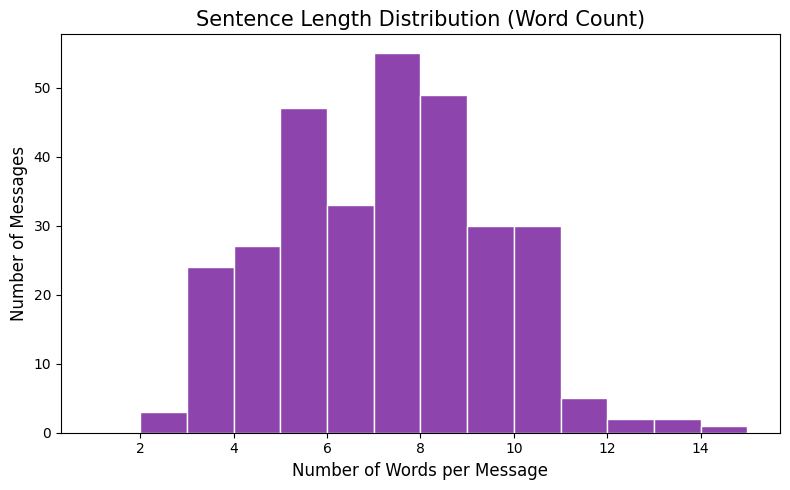

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['word_count'], bins=range(1, df['word_count'].max()+2), color='#8E44AD', edgecolor='white')
ax.set_title("Sentence Length Distribution (Word Count)", fontsize=15)
ax.set_xlabel("Number of Words per Message", fontsize=12)
ax.set_ylabel("Number of Messages", fontsize=12)
plt.tight_layout()
plt.show()



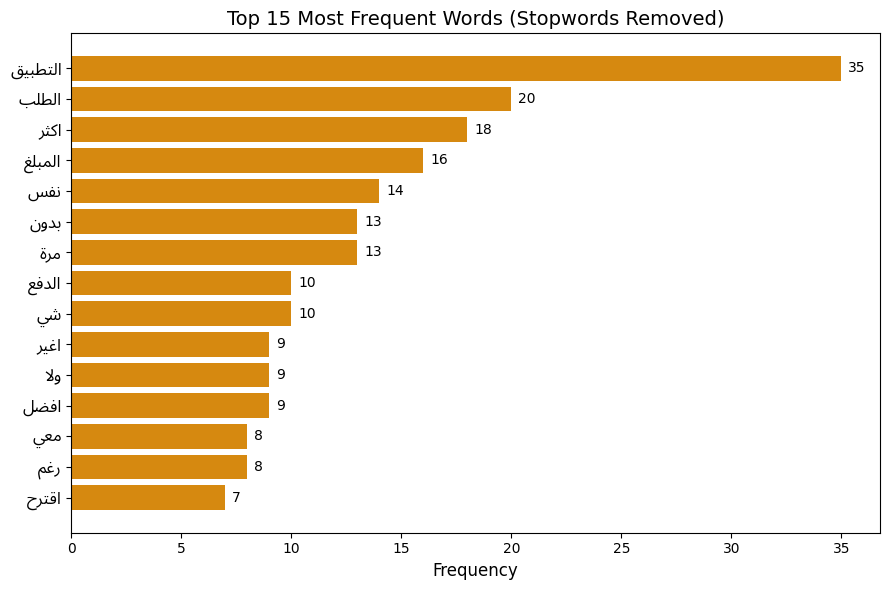

In [16]:
STOPWORDS = set("""
من في على إلى عن ما لا لم لن هل و ثم أو أن إن كان يكون هذا هذه ذلك تلك التي الذي
انا انت هو هي احنا هم كل بعد قبل مع بس عليه عليها فيه فيها لي له لها ياليت ممكن
اقدر ابغى ابي كيف وش ليش متى اذا لو حتى بين عند عندي عندك اللي مو ماكو فيه
""".split())

all_words = []
for text in df['text_clean']:
    words = [w for w in str(text).split() if w not in STOPWORDS and len(w) > 1 and not w.isdigit()]
    all_words.extend(words)

word_freq = Counter(all_words)
top_words = word_freq.most_common(15)

fig, ax = plt.subplots(figsize=(9, 6))
words_ar = [ar(w) for w, c in top_words]   # Arabic word labels need reshaping to render
counts = [c for w, c in top_words]
bars = ax.barh(words_ar[::-1], counts[::-1], color='#D68910')
ax.set_title("Top 15 Most Frequent Words (Stopwords Removed)", fontsize=14)
ax.set_xlabel("Frequency", fontsize=12)
for label in ax.get_yticklabels():
    label.set_fontproperties(arabic_font)
    label.set_fontsize(12)
for bar, val in zip(bars, counts[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=10)
plt.tight_layout()
plt.show()


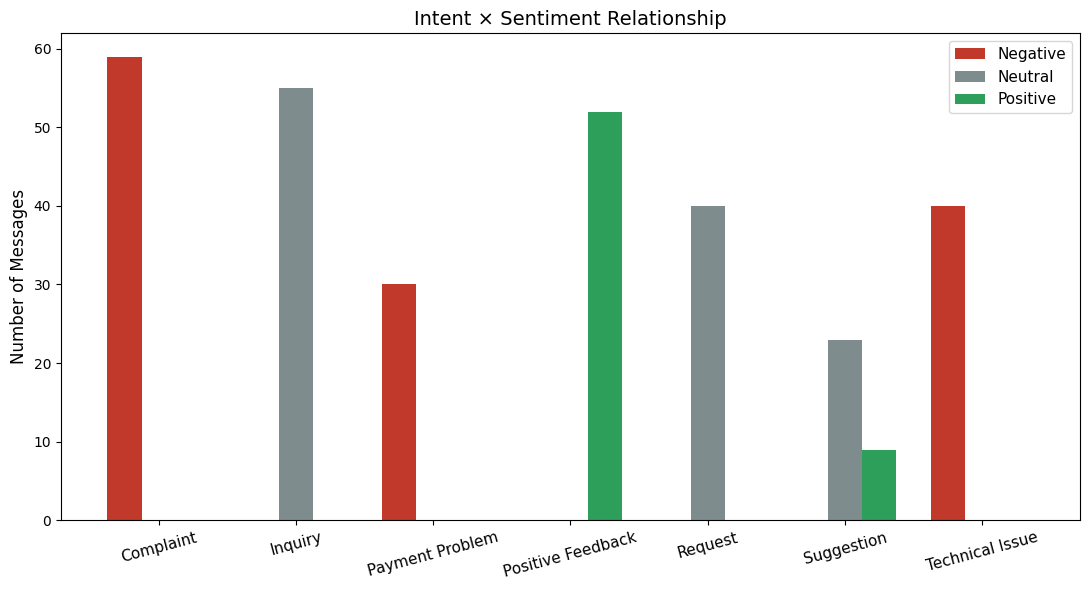

In [18]:
fig, ax = plt.subplots(figsize=(11, 6))
crosstab = pd.crosstab(df['intent'], df['sentiment'])
crosstab = crosstab[[c for c in ['Negative', 'Neutral', 'Positive'] if c in crosstab.columns]]
x = range(len(crosstab.index))
width = 0.25
sentiments_order = list(crosstab.columns)
for i, sent in enumerate(sentiments_order):
    offset = (i - len(sentiments_order)/2) * width + width/2
    ax.bar([xi + offset for xi in x], crosstab[sent], width, label=sent, color=colors.get(sent, '#888888'))
ax.set_xticks(list(x))
ax.set_xticklabels(crosstab.index, fontsize=11, rotation=15)
ax.set_title("Intent × Sentiment Relationship", fontsize=14)
ax.set_ylabel("Number of Messages", fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()



In [20]:
print("=== EDA Summary ===")
print(f"Total samples: {len(df)}")
print(f"Average word count: {df['word_count'].mean():.1f}")
print(f"Min / Max word count: {df['word_count'].min()} / {df['word_count'].max()}")
print(f"Largest intent class: {intent_counts.idxmax()} ({intent_counts.max()} samples)")
print(f"Smallest intent class: {intent_counts.idxmin()} ({intent_counts.min()} samples)")
print(f"Class imbalance ratio (largest/smallest): {intent_counts.max()/intent_counts.min():.1f}x")
print(f"Top 5 most frequent words: {[w for w, c in top_words[:5]]}")

=== EDA Summary ===
Total samples: 308
Average word count: 6.8
Min / Max word count: 2 / 14
Largest intent class: Complaint (59 samples)
Smallest intent class: Payment Problem (30 samples)
Class imbalance ratio (largest/smallest): 2.0x
Top 5 most frequent words: ['التطبيق', 'الطلب', 'اكثر', 'المبلغ', 'نفس']


In [23]:
import json
import warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

df = pd.read_csv("Clean_saudi_NLP.csv")
print(f"rows total: {len(df)}")
assert df["text_clean"].isnull().sum() == 0, "فيه قيم فارغة في text_clean!"


rows total: 308


In [24]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["intent"],
    random_state=RANDOM_STATE,
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["intent"],
    random_state=RANDOM_STATE,
)

print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# حفظ التقسيمات
train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)

# التحقق من توزيع الفئات عبر الأقسام
print("\n--- توزيع Intent عبر الأقسام ---")
dist = pd.DataFrame({
    "train": train_df["intent"].value_counts(),
    "val": val_df["intent"].value_counts(),
    "test": test_df["intent"].value_counts(),
}).fillna(0).astype(int)
print(dist)

print("\n--- توزيع Sentiment عبر الأقسام ---")
dist_s = pd.DataFrame({
    "train": train_df["sentiment"].value_counts(),
    "val": val_df["sentiment"].value_counts(),
    "test": test_df["sentiment"].value_counts(),
}).fillna(0).astype(int)
print(dist_s)

# تحذير لو أي فئة غابت عن أي قسم
for col in ["intent", "sentiment"]:
    for split_name, split_df in [("val", val_df), ("test", test_df)]:
        missing = set(df[col].unique()) - set(split_df[col].unique())
        if missing:
            print(f"⚠️  تحذير: الفئات {missing} غائبة عن {split_name} في عمود {col}")




Train: 246 | Val: 31 | Test: 31

--- توزيع Intent عبر الأقسام ---
                   train  val  test
intent                             
Complaint             47    6     6
Inquiry               44    5     6
Payment Problem       24    3     3
Positive Feedback     41    6     5
Request               32    4     4
Suggestion            26    3     3
Technical Issue       32    4     4

--- توزيع Sentiment عبر الأقسام ---
           train  val  test
sentiment                  
Negative     103   13    13
Neutral       94   12    12
Positive      49    6     6


In [25]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)

X_train = vectorizer.fit_transform(train_df["text_clean"])
X_val = vectorizer.transform(val_df["text_clean"])
X_test = vectorizer.transform(test_df["text_clean"])

print(f"\nحجم مفردات TF-IDF: {len(vectorizer.vocabulary_)}")
print(f"شكل X_train: {X_train.shape}")




حجم مفردات TF-IDF: 345
شكل X_train: (246, 345)


In [26]:
def evaluate(y_true, y_pred, labels):
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return {
        "accuracy": acc,
        "precision_macro": p_macro,
        "recall_macro": r_macro,
        "f1_macro": f1_macro,
        "precision_weighted": p_weighted,
        "recall_weighted": r_weighted,
        "f1_weighted": f1_weighted,
    }

tasks = {
    "intent": (train_df["intent"], val_df["intent"], test_df["intent"]),
    "sentiment": (train_df["sentiment"], val_df["sentiment"], test_df["sentiment"]),
}

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "SVM (LinearSVC)": LinearSVC(
        class_weight="balanced", random_state=RANDOM_STATE, max_iter=5000
    ),
}

all_results = []
predictions_store = {}

for task_name, (y_train, y_val, y_test) in tasks.items():
    print("\n" + "=" * 70)
    print(f"المهمة: {task_name.upper()}")
    print("=" * 70)
    labels = sorted(y_train.unique())

    for model_name, model in models.items():
        clf = model.__class__(**model.get_params())
        clf.fit(X_train, y_train)

        val_pred = clf.predict(X_val)
        test_pred = clf.predict(X_test)

        val_metrics = evaluate(y_val, val_pred, labels)
        test_metrics = evaluate(y_test, test_pred, labels)

        all_results.append({
            "task": task_name, "model": model_name, "split": "val", **val_metrics
        })
        all_results.append({
            "task": task_name, "model": model_name, "split": "test", **test_metrics
        })

        predictions_store[f"{task_name}__{model_name}"] = {
            "y_test": list(y_test), "y_pred": list(test_pred)
        }

        print(f"\n>> {model_name}")
        print(f"   Val  -> Acc: {val_metrics['accuracy']:.3f} | "
              f"F1(macro): {val_metrics['f1_macro']:.3f} | "
              f"F1(weighted): {val_metrics['f1_weighted']:.3f}")
        print(f"   Test -> Acc: {test_metrics['accuracy']:.3f} | "
              f"F1(macro): {test_metrics['f1_macro']:.3f} | "
              f"F1(weighted): {test_metrics['f1_weighted']:.3f}")
        print("\n   -- Classification Report (Test) --")
        print(classification_report(y_test, test_pred, zero_division=0))




المهمة: INTENT

>> Logistic Regression
   Val  -> Acc: 0.806 | F1(macro): 0.824 | F1(weighted): 0.813
   Test -> Acc: 0.677 | F1(macro): 0.698 | F1(weighted): 0.688

   -- Classification Report (Test) --
                   precision    recall  f1-score   support

        Complaint       0.50      0.67      0.57         6
          Inquiry       1.00      0.83      0.91         6
  Payment Problem       0.67      0.67      0.67         3
Positive Feedback       0.43      0.60      0.50         5
          Request       1.00      0.50      0.67         4
       Suggestion       1.00      1.00      1.00         3
  Technical Issue       0.67      0.50      0.57         4

         accuracy                           0.68        31
        macro avg       0.75      0.68      0.70        31
     weighted avg       0.74      0.68      0.69        31


>> SVM (LinearSVC)
   Val  -> Acc: 0.742 | F1(macro): 0.738 | F1(weighted): 0.744
   Test -> Acc: 0.677 | F1(macro): 0.682 | F1(weighted): 0.6

In [27]:
results_df = pd.DataFrame(all_results)
results_df = results_df[[
    "task", "model", "split", "accuracy", "precision_macro", "recall_macro",
    "f1_macro", "precision_weighted", "recall_weighted", "f1_weighted"
]]
results_df.to_csv("baseline_results.csv", index=False)

print("\n" + "=" * 70)
print("جدول المقارنة النهائي (Test set فقط)")
print("=" * 70)
final_table = results_df[results_df["split"] == "test"].drop(columns=["split"])
final_table = final_table.round(3)
print(final_table.to_string(index=False))

# حفظ التنبؤات للتحليل اللاحق (مثلاً مقارنة الأخطاء مع MARBERT)
with open("test_predictions.json", "w", encoding="utf-8") as f:
    json.dump(predictions_store, f, ensure_ascii=False, indent=2)

print("\n✅ تم الانتهاء. الملفات المحفوظة:")
print("   - train.csv / val.csv / test.csv")
print("   - baseline_results.csv (جدول المقاييس الكامل)")
print("   - test_predictions.json (تنبؤات الاختبار للمقارنة لاحقًا)")




جدول المقارنة النهائي (Test set فقط)
     task               model  accuracy  precision_macro  recall_macro  f1_macro  precision_weighted  recall_weighted  f1_weighted
   intent Logistic Regression     0.677            0.752         0.681     0.698               0.736            0.677        0.688
   intent     SVM (LinearSVC)     0.677            0.752         0.681     0.682               0.752            0.677        0.684
sentiment Logistic Regression     0.645            0.630         0.622     0.621               0.679            0.645        0.658
sentiment     SVM (LinearSVC)     0.613            0.566         0.566     0.566               0.613            0.613        0.613

✅ تم الانتهاء. الملفات المحفوظة:
   - train.csv / val.csv / test.csv
   - baseline_results.csv (جدول المقاييس الكامل)
   - test_predictions.json (تنبؤات الاختبار للمقارنة لاحقًا)


# Part 2 — Cross-Validation + Char n-grams + Naive Bayes

**Why this part?** The Test set has only 31 rows, so one wrong prediction moves accuracy by ~3.2%.
Cross-validation over all 308 rows gives a much more stable estimate.
We also try **character n-grams** (helps with dialect spelling variation like "مرره" / "مررره")
and **Naive Bayes** as a third classical baseline.

In [ ]:
# ---- Cell A: Cross-validation over all 308 rows (TF-IDF is fitted INSIDE each fold -> no leakage) ----
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.naive_bayes import MultinomialNB, ComplementNB

def word_tfidf():
    return TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)

def char_tfidf():
    return TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), min_df=2, sublinear_tf=True)

def word_plus_char():
    return FeatureUnion([("word", word_tfidf()), ("char", char_tfidf())])

cv_models = {
    "LR  (word)":       Pipeline([("tfidf", word_tfidf()),      ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
    "SVM (word)":       Pipeline([("tfidf", word_tfidf()),      ("clf", LinearSVC(class_weight="balanced"))]),
    "MNB (word)":       Pipeline([("tfidf", word_tfidf()),      ("clf", MultinomialNB())]),
    "CNB (word)":       Pipeline([("tfidf", word_tfidf()),      ("clf", ComplementNB())]),
    "LR  (word+char)":  Pipeline([("tfidf", word_plus_char()),  ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
    "SVM (word+char)":  Pipeline([("tfidf", word_plus_char()),  ("clf", LinearSVC(class_weight="balanced"))]),
}

cv_rows = []
for task in ["intent", "sentiment"]:
    y = df[task]
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
    for name, pipe in cv_models.items():
        r = cross_validate(pipe, df["text_clean"], y, cv=cv, scoring=["accuracy", "f1_macro"])
        cv_rows.append({
            "task": task, "model": name,
            "acc_mean": r["test_accuracy"].mean(), "acc_std": r["test_accuracy"].std(),
            "f1_macro_mean": r["test_f1_macro"].mean(), "f1_macro_std": r["test_f1_macro"].std(),
        })

cv_df = pd.DataFrame(cv_rows)
cv_df.to_csv("cv_results.csv", index=False)
print(cv_df.round(3).to_string(index=False))

In [ ]:
# ---- Cell B: Visual comparison of the CV results (error bars = std across the 15 folds) ----
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=False)
for ax, task in zip(axes, ["intent", "sentiment"]):
    sub = cv_df[cv_df["task"] == task].reset_index(drop=True)
    ax.barh(sub["model"], sub["f1_macro_mean"], xerr=sub["f1_macro_std"],
            color="#2E6E9E", capsize=3)
    ax.set_title(f"{task.capitalize()} — CV F1 (macro)", fontsize=13)
    ax.set_xlim(0.5, 0.9)
    ax.invert_yaxis()
    for i, v in enumerate(sub["f1_macro_mean"]):
        ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# ---- Cell C: Best config (LR word+char) on the SAME Train/Val/Test split, next to the word-only baseline ----
# NOTE: Test is still only 31 rows -> treat these numbers as noisy. Prefer the CV table above for conclusions.
best_vec = word_plus_char()
Xtr = best_vec.fit_transform(train_df["text_clean"])   # fit on Train only
Xva = best_vec.transform(val_df["text_clean"])
Xte = best_vec.transform(test_df["text_clean"])

rows = []
for task_name, (y_tr, y_va, y_te) in tasks.items():
    clf = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
    clf.fit(Xtr, y_tr)
    for split_name, X_, y_ in [("val", Xva, y_va), ("test", Xte, y_te)]:
        m = evaluate(y_, clf.predict(X_), sorted(y_tr.unique()))
        rows.append({"task": task_name, "model": "LR (word+char)", "split": split_name, **m})

best_df = pd.DataFrame(rows)
best_df.to_csv("best_config_results.csv", index=False)

baseline = results_df[(results_df["model"] == "Logistic Regression") & (results_df["split"] == "test")].copy()
baseline["model"] = "LR (word only)"
compare = pd.concat([baseline, best_df[best_df["split"] == "test"]])
print(compare[["task", "model", "accuracy", "f1_macro", "f1_weighted"]].round(3).to_string(index=False))

### How to read this
- **Trust the CV table (Cell A/B) more than the single Test split** — 15 folds over 308 rows vs. 31 rows.
- Expected pattern: word+char n-grams give a small but consistent gain; Naive Bayes (Complement) is close to LR but not better; plain MultinomialNB is weaker.
- Keep the 80/10/10 Test predictions for the MARBERT comparison (same 31 rows), and report the CV numbers next to them.